### **Problem 3**
In this problem, we will use multiple linear regression to predict the fuel consumption of cars (measured in
miles per gallon).  
The available predictors are: (i) cylinders, (ii) displacement, (iii) horsepower, (iv) weight, (v) acceleration and (vi) model year.  
The dataset is named auto-mpg.csv, and can be found in Canvas.  

R2 = 0.809


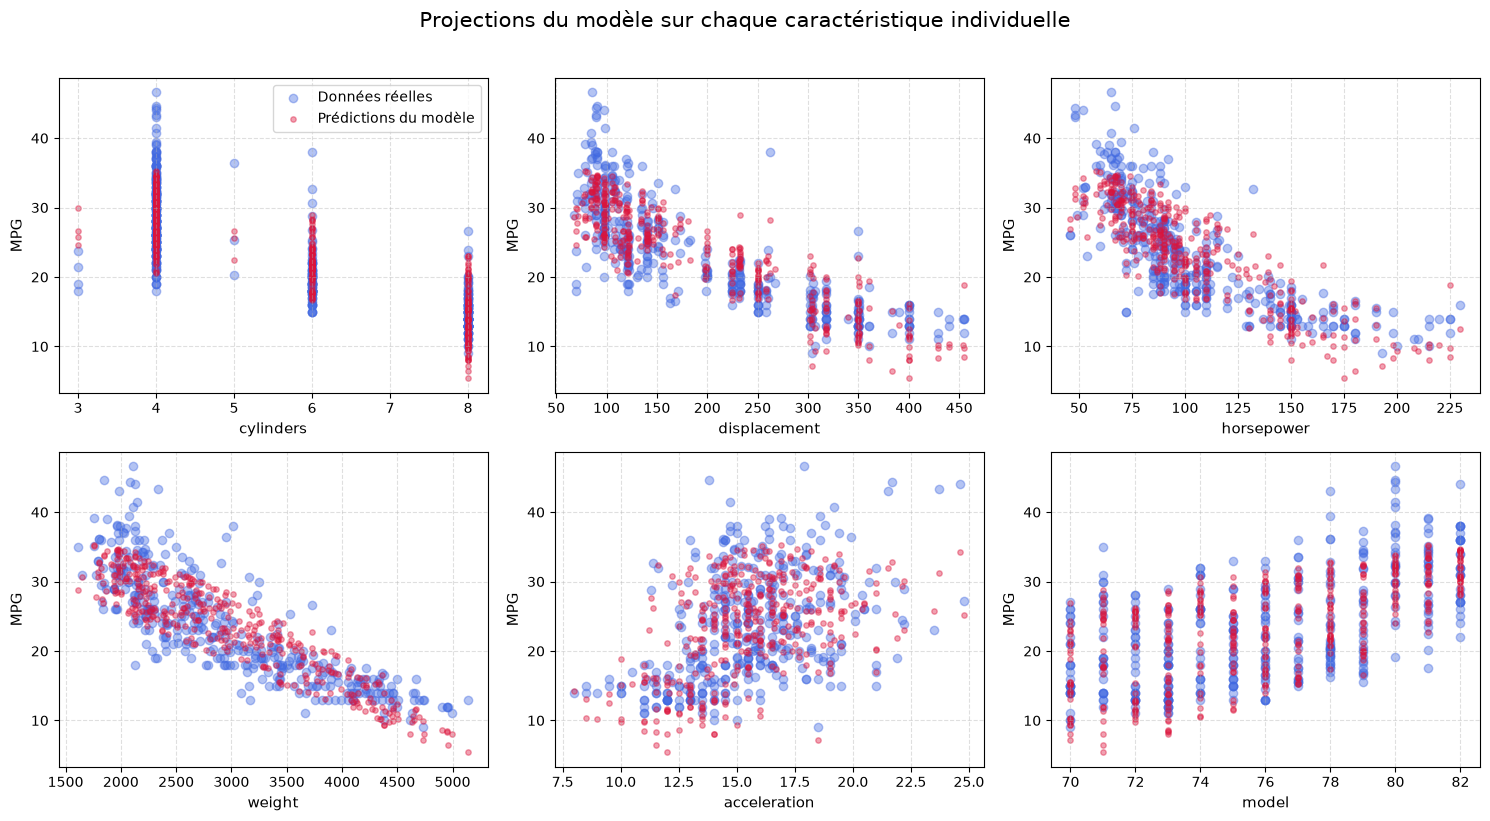

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

data = pd.read_csv('auto-mpg.csv',
                    comment='#', header=None, sep=' ')
data.columns = ['mpg', 'cylinders', 'displacement', 'horsepower',
                 'weight', 'acceleration', 'model']

y  = data['mpg']         .to_numpy()
x1 = data['cylinders']   .to_numpy()
x2 = data['displacement'].to_numpy()
x3 = data['horsepower']  .to_numpy()
x4 = data['weight']      .to_numpy()
x5 = data['acceleration'].to_numpy()
x6 = data['model']       .to_numpy()

X = np.array([x1, x2, x3, x4, x5, x6, np.ones(len(x1))]).T

a_opt = np.linalg.inv(X.T @ X) @ X.T @ y # 3. Calculer les coefficients optimaux a* = (X^T X)^(-1) X^T y

y_hat = X @ a_opt

# calcul des résiduels et de R2
SSres = np.sum((y - y_hat)**2)
SStot = np.sum((y - np.mean(y))**2)
r2 = 1 - (SSres/SStot)
print(f'R2 = {r2:.3f}')

# plt.figure(figsize=(7, 7))
# plt.scatter(y, y_hat, alpha=0.6, color="royalblue", edgecolors="k", s=35)

# # Ligne diagonale idéale : y_pred = y_vrai
# lims = [min(y.min(), y_hat.min()), max(y.max(), y_hat.max())]
# plt.plot(lims, lims, "r--", linewidth=2, label="Ajustement idéal ($y = \hat{y}$)")

# plt.xlabel("Valeurs réelles (MPG)", fontsize=12)
# plt.ylabel("Valeurs prédites $\hat{y}$ (MPG)", fontsize=12)
# plt.title(
#     f"Prédictions vs Réel (Régression Multiple 6D) - $R^2 = {r2:.3f}$",
#     fontsize=13,
# )
# plt.legend()
# plt.grid(True, linestyle="--", alpha=0.5)
# plt.axis("equal")
# plt.show()

# res = y - y_hat

# plt.figure(figsize=(9, 5))
# plt.scatter(y_hat, res, color="tab:red", alpha=0.6, edgecolors="k", s=35)
# plt.axhline(0, color="black", linestyle="--", linewidth=1.5)

# plt.xlabel("Valeurs prédites $\hat{y}$ (MPG)", fontsize=12)
# plt.ylabel("Résidus ($y - \hat{y}$)", fontsize=12)
# plt.title("Graphique des résidus vs Prédictions", fontsize=13)
# plt.grid(True, linestyle="--", alpha=0.5)
# plt.show()

features = [
    "cylinders",
    "displacement",
    "horsepower",
    "weight",
    "acceleration",
    "model",
]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, feat_name in enumerate(features):
    axes[i].scatter(
        data[feat_name], y, color="royalblue", alpha=0.4, label="Données réelles"
    )
    axes[i].scatter(
        data[feat_name],
        y_hat,
        color="crimson",
        alpha=0.4,
        s=15,
        label="Prédictions du modèle",
    )
    axes[i].set_xlabel(feat_name, fontsize=11)
    axes[i].set_ylabel("MPG", fontsize=11)
    axes[i].grid(True, linestyle="--", alpha=0.4)
    if i == 0:
        axes[i].legend()

plt.suptitle(
    "Projections du modèle sur chaque caractéristique individuelle",
    fontsize=15,
    y=1.02,
)
plt.tight_layout()
plt.show()



**(3a)** Implement your own function for estimating the linear-regression parameters, and use this to fit a regression
model to the fuel-consumption data.

**(3b)** Explain why the magnitudes of the estimated coefficients are so different. What could be done to prevent
this from happening?

**(3c)** Compute R2 and use this to evaluate the quality of your model.

**(3d)** Experiment with removing different predictors from the model. Do you think all predictors are equally
necessary? Explain.